In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel('../data/raw/online_retail.xlsx', engine='openpyxl')

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Data types:")
print(df.dtypes)
df.head()

Shape: (541909, 8)
Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']
Data types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [2]:
# Score each dimension 1-5 using quintiles (5 equal-sized buckets)

# Recency: LOWER is better (recent = good), so best recency gets score 5.
# We reverse the labels: smallest days -> 5, largest days -> 1
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=5, labels=[5, 4, 3, 2, 1]).astype(int)

# Frequency: HIGHER is better. We rank first to break ties, then cut into 5.
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5]).astype(int)

# Monetary: HIGHER is better.
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=5, labels=[1, 2, 3, 4, 5]).astype(int)

# Combine into an overall RFM score (sum, ranges 3-15)
rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

print(rfm[['CustomerID', 'Recency', 'Frequency', 'Monetary', 
           'R_Score', 'F_Score', 'M_Score', 'RFM_Score']].head(10))
print("\nRFM_Score distribution:")
print(rfm['RFM_Score'].value_counts().sort_index())

NameError: name 'rfm' is not defined

In [ ]:
import pandas as pd
import numpy as np

# Reload clean data
df = pd.read_csv('../data/processed/online_retail_clean.csv')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Build RFM
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
rfm = df.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('InvoiceNo',   'nunique'),
    Monetary  = ('TotalPrice',  'sum')
).reset_index()

# Score 1-5
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

print(rfm[['CustomerID', 'Recency', 'Frequency', 'Monetary',
           'R_Score', 'F_Score', 'M_Score', 'RFM_Score']].head(10))
print("\nRFM_Score distribution:")
print(rfm['RFM_Score'].value_counts().sort_index())

   CustomerID  Recency  Frequency  Monetary  R_Score  F_Score  M_Score  \
0       12346      326          1  77183.60        1        1        5   
1       12347        2          7   4310.00        5        5        5   
2       12348       75          4   1797.24        2        4        4   
3       12349       19          1   1757.55        4        1        4   
4       12350      310          1    334.40        1        1        2   
5       12352       36          8   2506.04        3        5        5   
6       12353      204          1     89.00        1        1        1   
7       12354      232          1   1079.40        1        1        4   
8       12355      214          1    459.40        1        1        2   
9       12356       23          3   2811.43        4        3        5   

   RFM_Score  
0          7  
1         15  
2         10  
3          9  
4          4  
5         13  
6          3  
7          6  
8          4  
9         12  

RFM_Score distribut

In [ ]:
# Map RFM scores into named business segments based on R and F.
# We use a function that looks at the Recency and Frequency scores
# to assign each customer a meaningful label.

def segment_customer(row):
    r, f = row['R_Score'], row['F_Score']
    if r >= 4 and f >= 4:
        return 'Champions'          # recent + frequent = your best
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'    # solid regulars
    elif r >= 4 and f <= 2:
        return 'New Customers'      # bought recently, not often yet
    elif r >= 3 and f <= 2:
        return 'Promising'          # fairly recent, low frequency
    elif r <= 2 and f >= 3:
        return 'At Risk'            # used to buy often, gone quiet — WIN BACK
    elif r <= 2 and f <= 2:
        return 'Lost'               # gone, infrequent
    else:
        return 'Needs Attention'    # everyone else

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

# How many customers in each segment?
print("Customers per segment:")
print(rfm['Segment'].value_counts())

# Average R, F, M per segment — this is the business-interpretation table
print("\nSegment profiles (averages):")
print(rfm.groupby('Segment').agg(
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    Count=('CustomerID', 'count')
).round(1).sort_values('Avg_Monetary', ascending=False))

Customers per segment:
Segment
Champions          1139
Lost               1065
Loyal Customers     821
At Risk             643
Promising           351
New Customers       319
Name: count, dtype: int64

Segment profiles (averages):
                 Avg_Recency  Avg_Frequency  Avg_Monetary  Count
Segment                                                         
Champions               13.3           10.0        5204.3   1139
Loyal Customers         38.0            3.6        1651.3    821
At Risk                152.8            3.4        1245.0    643
Lost                   217.9            1.1         487.7   1065
Promising               53.5            1.2         461.1    351
New Customers           18.5            1.2         458.2    319


In [ ]:
# Save the RFM table with scores and segments for Day 3 clustering
rfm.to_csv('../data/processed/rfm_features.csv', index=False)
print("Saved RFM features:", rfm.shape)
print("Columns:", rfm.columns.tolist())

Saved RFM features: (4338, 9)
Columns: ['CustomerID', 'Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score', 'Segment']


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Load the RFM features from Day 2
rfm = pd.read_csv('../data/processed/rfm_features.csv')

# Take just the three raw RFM values for clustering
rfm_features = rfm[['Recency', 'Frequency', 'Monetary']].copy()

# 1. Log transform to reduce skew.
#    log1p = log(1 + x), which safely handles any zeros.
rfm_log = np.log1p(rfm_features)

# 2. Standardize: each column -> mean 0, std 1, so all are on equal footing.
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

print("Before scaling (raw):")
print(rfm_features.describe().round(1))
print("\nAfter log + scaling (means ~0, std ~1):")
print(pd.DataFrame(rfm_scaled, columns=['R','F','M']).describe().round(2))

Before scaling (raw):
       Recency  Frequency  Monetary
count   4338.0     4338.0    4338.0
mean      92.5        4.3    2054.3
std      100.0        7.7    8989.2
min        1.0        1.0       3.8
25%       18.0        1.0     307.4
50%       51.0        2.0     674.5
75%      142.0        5.0    1661.7
max      374.0      209.0  280206.0

After log + scaling (means ~0, std ~1):
             R        F        M
count  4338.00  4338.00  4338.00
mean     -0.00    -0.00     0.00
std       1.00     1.00     1.00
min      -2.34    -0.96    -4.00
25%      -0.66    -0.96    -0.69
50%       0.09    -0.36    -0.06
75%       0.84     0.65     0.65
max       1.56     5.86     4.73


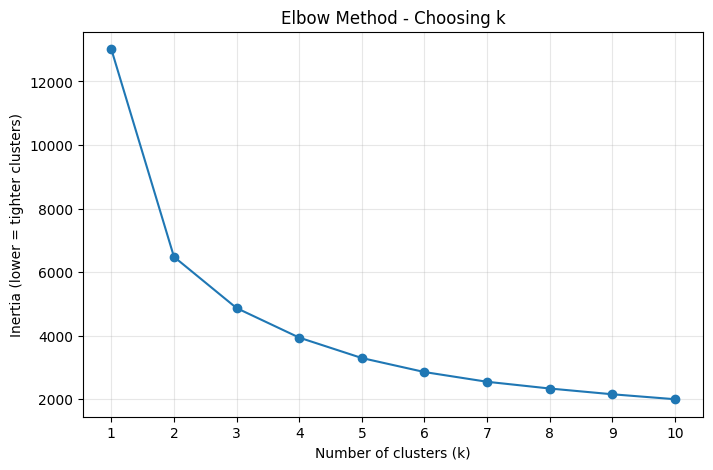

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Try k from 1 to 10 and record the inertia for each
inertias = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertias.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker='o')
plt.title('Elbow Method - Choosing k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (lower = tighter clusters)')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.savefig('../models/elbow_method.png', dpi=100, bbox_inches='tight')
plt.show()

In [ ]:
# Train the final model with our chosen k
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# Profile each cluster: average R, F, M + size
cluster_profile = rfm.groupby('Cluster').agg(
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    Count=('CustomerID', 'count')
).round(1)

print("Cluster profiles:")
print(cluster_profile.sort_values('Avg_Monetary', ascending=False))

Cluster profiles:
         Avg_Recency  Avg_Frequency  Avg_Monetary  Count
Cluster                                                 
1               12.1           13.7        8074.3    716
2               71.1            4.1        1802.8   1173
0               18.1            2.1         551.8    837
3              182.5            1.3         343.5   1612


In [ ]:
# Map cluster numbers to business names (based on the profiles above)
cluster_names = {
    1: 'Champions',
    2: 'Loyal Customers',
    0: 'Recent Low-Value',
    3: 'At Risk / Lost'
}
rfm['Cluster_Name'] = rfm['Cluster'].map(cluster_names)

print(rfm['Cluster_Name'].value_counts())

# Save the final clustered data
rfm.to_csv('../data/processed/rfm_clustered.csv', index=False)
print("\nSaved final clustered customer data!")

Cluster_Name
At Risk / Lost      1612
Loyal Customers     1173
Recent Low-Value     837
Champions            716
Name: count, dtype: int64

Saved final clustered customer data!


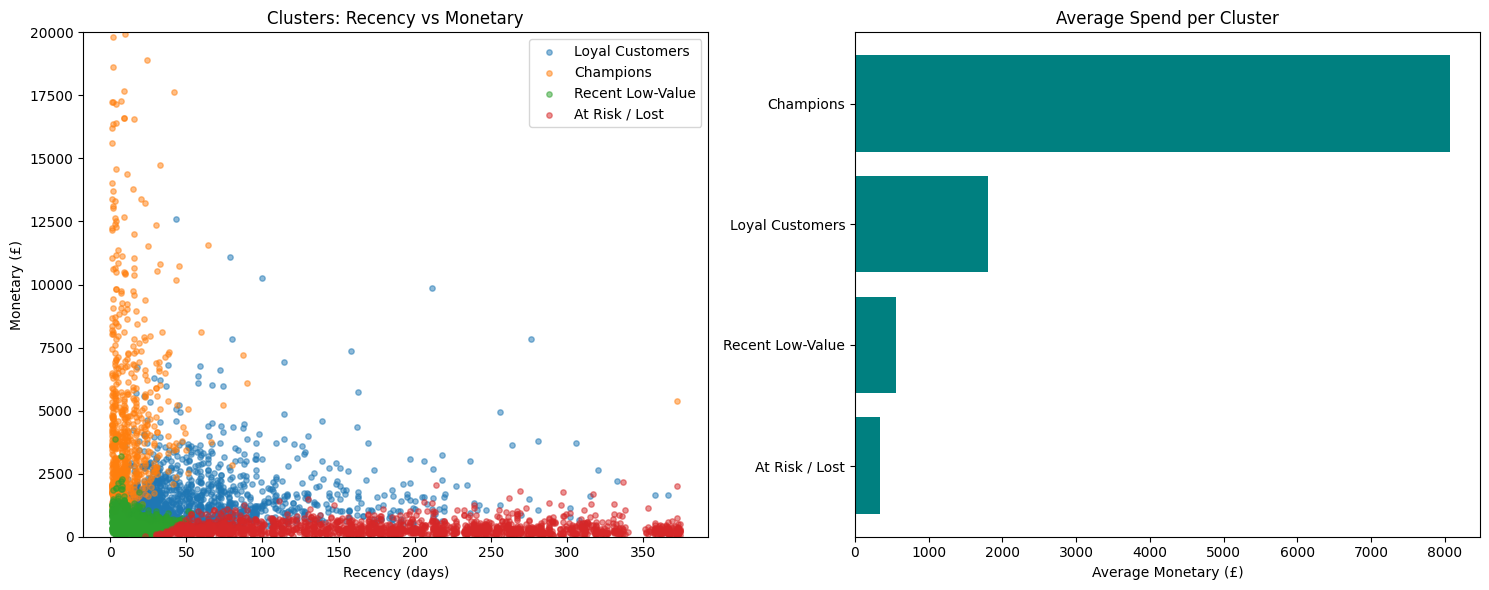

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Scatter: Recency vs Monetary, colored by cluster
for name in rfm['Cluster_Name'].unique():
    sub = rfm[rfm['Cluster_Name'] == name]
    axes[0].scatter(sub['Recency'], sub['Monetary'], label=name, alpha=0.5, s=15)
axes[0].set_xlabel('Recency (days)'); axes[0].set_ylabel('Monetary (£)')
axes[0].set_title('Clusters: Recency vs Monetary')
axes[0].set_ylim(0, 20000)  # cap to see the bulk, not whales
axes[0].legend()

# Bar: average monetary per cluster
prof = rfm.groupby('Cluster_Name')['Monetary'].mean().sort_values()
axes[1].barh(prof.index, prof.values, color='teal')
axes[1].set_xlabel('Average Monetary (£)')
axes[1].set_title('Average Spend per Cluster')

plt.tight_layout()
plt.savefig('../models/customer_clusters.png', dpi=100, bbox_inches='tight')
plt.show()

In [ ]:
%pip install openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [openpyxl]1/2 [openpyxl]

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
print("Missing values per column:")
print(df.isnull().sum())

print("\nPercentage missing:")
print((df.isnull().sum() / len(df) * 100).round(2))

df.describe()

Missing values per column:


NameError: name 'df' is not defined

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel('../data/raw/online_retail.xlsx', engine='openpyxl')

print("Missing values per column:")
print(df.isnull().sum())

print("\nPercentage missing:")
print((df.isnull().sum() / len(df) * 100).round(2))

df.describe()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel('../data/raw/online_retail.xlsx', engine='openpyxl')

print("Missing values per column:")
print(df.isnull().sum())

print("\nPercentage missing:")
print((df.isnull().sum() / len(df) * 100).round(2))

df.describe()

Missing values per column:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Percentage missing:
InvoiceNo       0.00
StockCode       0.00
Description     0.27
Quantity        0.00
InvoiceDate     0.00
UnitPrice       0.00
CustomerID     24.93
Country         0.00
dtype: float64


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [ ]:
# Start from the raw data, make a copy so we keep the original intact
df_clean = df.copy()

# 1. Drop rows with no CustomerID — needed for segmentation & churn
df_clean = df_clean.dropna(subset=['CustomerID'])

# 2. Drop rows with no product Description (junk rows)
df_clean = df_clean.dropna(subset=['Description'])

# 3. Remove returns/cancellations — keep only real sales (Quantity > 0)
df_clean = df_clean[df_clean['Quantity'] > 0]

# 4. Remove zero/negative prices — not valid sales
df_clean = df_clean[df_clean['UnitPrice'] > 0]

# 5. CustomerID should be a whole number, not 17850.0 — convert to int
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)

# 6. Create a TotalPrice column — useful for revenue analysis & RFM later
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

# Compare before and after
print("Original rows:", len(df))
print("Cleaned rows: ", len(df_clean))
print("Rows removed: ", len(df) - len(df_clean), 
      f"({(len(df)-len(df_clean))/len(df)*100:.1f}%)")
print("\nCleaned data check:")
print(df_clean.describe())

Original rows: 541909
Cleaned rows:  397884
Rows removed:  144025 (26.6%)

Cleaned data check:
            Quantity                    InvoiceDate      UnitPrice  \
count  397884.000000                         397884  397884.000000   
mean       12.988238  2011-07-10 23:41:23.511023360       3.116488   
min         1.000000            2010-12-01 08:26:00       0.001000   
25%         2.000000            2011-04-07 11:12:00       1.250000   
50%         6.000000            2011-07-31 14:39:00       1.950000   
75%        12.000000            2011-10-20 14:33:00       3.750000   
max     80995.000000            2011-12-09 12:50:00    8142.750000   
std       179.331775                            NaN      22.097877   

          CustomerID     TotalPrice  
count  397884.000000  397884.000000  
mean    15294.423453      22.397000  
min     12346.000000       0.001000  
25%     13969.000000       4.680000  
50%     15159.000000      11.800000  
75%     16795.000000      19.800000  
max     

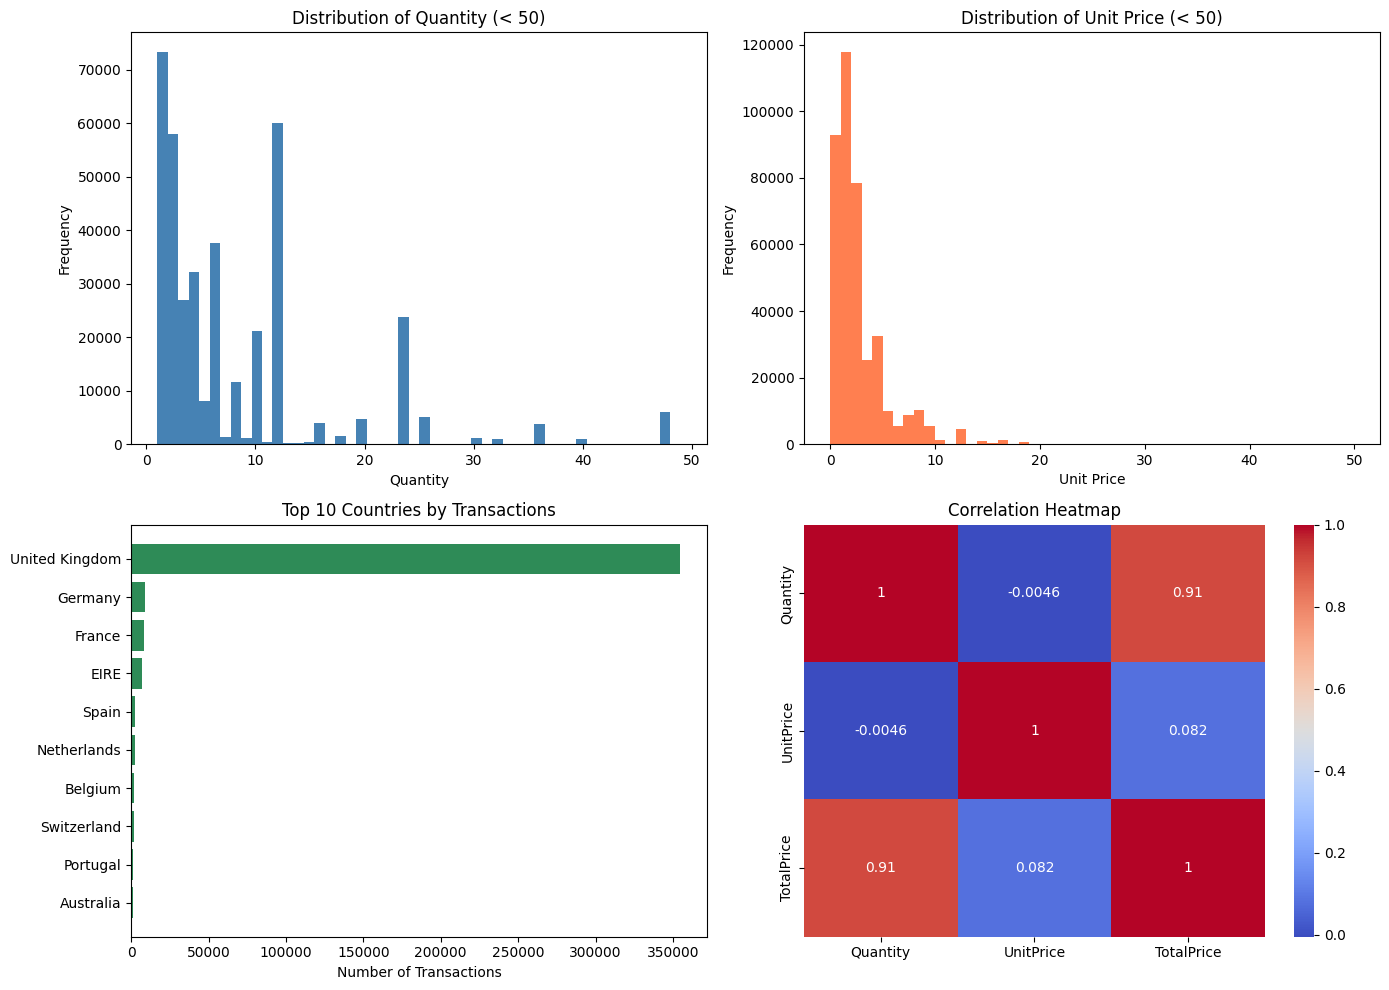

In [ ]:
# Set up a 2x2 grid of plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribution of Quantity (capped at 50 to see the bulk, not outliers)
axes[0,0].hist(df_clean[df_clean['Quantity'] < 50]['Quantity'], bins=50, color='steelblue')
axes[0,0].set_title('Distribution of Quantity (< 50)')
axes[0,0].set_xlabel('Quantity'); axes[0,0].set_ylabel('Frequency')

# 2. Distribution of UnitPrice (capped at 50)
axes[0,1].hist(df_clean[df_clean['UnitPrice'] < 50]['UnitPrice'], bins=50, color='coral')
axes[0,1].set_title('Distribution of Unit Price (< 50)')
axes[0,1].set_xlabel('Unit Price'); axes[0,1].set_ylabel('Frequency')

# 3. Top 10 countries by number of transactions
top_countries = df_clean['Country'].value_counts().head(10)
axes[1,0].barh(top_countries.index[::-1], top_countries.values[::-1], color='seagreen')
axes[1,0].set_title('Top 10 Countries by Transactions')
axes[1,0].set_xlabel('Number of Transactions')

# 4. Correlation heatmap of numeric columns
numeric_cols = ['Quantity', 'UnitPrice', 'TotalPrice']
sns.heatmap(df_clean[numeric_cols].corr(), annot=True, cmap='coolwarm', ax=axes[1,1])
axes[1,1].set_title('Correlation Heatmap')

plt.tight_layout()
plt.savefig('../models/eda_overview.png', dpi=100, bbox_inches='tight')
plt.show()

In [ ]:
# Save cleaned data so Day 2 can load it instantly
df_clean.to_csv('../data/processed/online_retail_clean.csv', index=False)
print("Saved! Shape:", df_clean.shape)

Saved! Shape: (397884, 9)


In [ ]:
import pandas as pd
import numpy as np

# Load the cleaned data we saved in Day 1
df = pd.read_csv('../data/processed/online_retail_clean.csv')

# CSV doesn't remember dates are dates, so convert InvoiceDate back to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print("Loaded:", df.shape)
df.head()

Loaded: (397884, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [ ]:
# Set a "snapshot date" = the day after the last transaction.
# We pretend we're analyzing the data one day after the last sale,
# so Recency = days between a customer's last purchase and this date.
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print("Snapshot date:", snapshot_date)

# Group by customer and compute R, F, M
rfm = df.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('InvoiceNo',   'nunique'),   # count of distinct orders
    Monetary  = ('TotalPrice',  'sum')        # total money spent
).reset_index()

print("\nRFM table shape:", rfm.shape)
print(rfm.head())
print("\nRFM summary:")
print(rfm.describe())

Snapshot date: 2011-12-10 12:50:00

RFM table shape: (4338, 4)
   CustomerID  Recency  Frequency  Monetary
0       12346      326          1  77183.60
1       12347        2          7   4310.00
2       12348       75          4   1797.24
3       12349       19          1   1757.55
4       12350      310          1    334.40

RFM summary:
         CustomerID      Recency    Frequency       Monetary
count   4338.000000  4338.000000  4338.000000    4338.000000
mean   15300.408022    92.536422     4.272015    2054.266460
std     1721.808492   100.014169     7.697998    8989.230441
min    12346.000000     1.000000     1.000000       3.750000
25%    13813.250000    18.000000     1.000000     307.415000
50%    15299.500000    51.000000     2.000000     674.485000
75%    16778.750000   142.000000     5.000000    1661.740000
max    18287.000000   374.000000   209.000000  280206.020000


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Reload clean data
df = pd.read_csv('../data/processed/online_retail_clean.csv')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Collapse to ONE row per day = total quantity sold that day
daily = df.groupby(df['InvoiceDate'].dt.date).agg(
    Quantity=('Quantity', 'sum'),
    Revenue=('TotalPrice', 'sum'),
    Orders=('InvoiceNo', 'nunique')
).reset_index()

# Make the date a proper datetime and sort
daily['InvoiceDate'] = pd.to_datetime(daily['InvoiceDate'])
daily = daily.sort_values('InvoiceDate').reset_index(drop=True)

print("Daily series shape:", daily.shape)
print("Date range:", daily['InvoiceDate'].min(), "→", daily['InvoiceDate'].max())
print(daily.head())
print(daily.describe().round(0))

Daily series shape: (305, 4)
Date range: 2010-12-01 00:00:00 → 2011-12-09 00:00:00
  InvoiceDate  Quantity   Revenue  Orders
0  2010-12-01     24215  46376.49     121
1  2010-12-02     31142  47316.53     137
2  2010-12-03     11839  23921.71      57
3  2010-12-05     16449  31771.60      87
4  2010-12-06     16291  31215.64      94
                         InvoiceDate  Quantity   Revenue  Orders
count                            305     305.0     305.0   305.0
mean   2011-06-10 20:03:56.065573888   16944.0   29218.0    61.0
min              2010-12-01 00:00:00    2048.0    3457.0    11.0
25%              2011-03-10 00:00:00   10831.0   18021.0    44.0
50%              2011-06-14 00:00:00   15122.0   25490.0    58.0
75%              2011-09-12 00:00:00   20863.0   36751.0    72.0
max              2011-12-09 00:00:00   90582.0  184349.0   137.0
std                              NaN   10129.0   17855.0    25.0


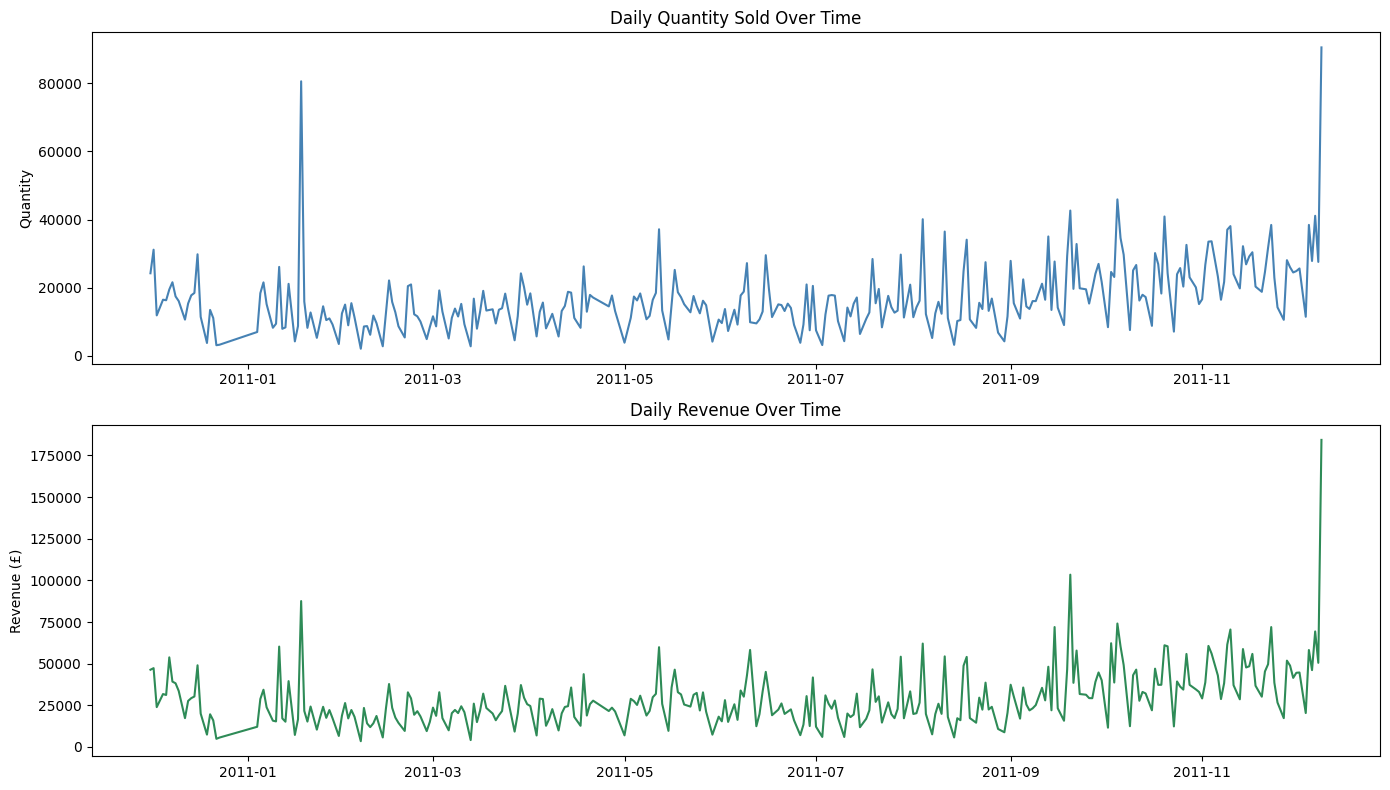

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(14, 8))

ax[0].plot(daily['InvoiceDate'], daily['Quantity'], color='steelblue')
ax[0].set_title('Daily Quantity Sold Over Time')
ax[0].set_ylabel('Quantity')

ax[1].plot(daily['InvoiceDate'], daily['Revenue'], color='seagreen')
ax[1].set_title('Daily Revenue Over Time')
ax[1].set_ylabel('Revenue (£)')

plt.tight_layout()
plt.savefig('../models/daily_sales_timeseries.png', dpi=100, bbox_inches='tight')
plt.show()

In [ ]:
# Drop the last day - it's an incomplete/artifact spike that would distort training
daily_clean = daily[daily['InvoiceDate'] < '2011-12-09'].copy()

# Prophet REQUIRES exactly two columns named 'ds' (date) and 'y' (value)
prophet_df = daily_clean[['InvoiceDate', 'Quantity']].rename(
    columns={'InvoiceDate': 'ds', 'Quantity': 'y'}
)

print("Rows for modeling:", len(prophet_df))
print(prophet_df.head())
print("Last few rows:")
print(prophet_df.tail())

Rows for modeling: 304
          ds      y
0 2010-12-01  24215
1 2010-12-02  31142
2 2010-12-03  11839
3 2010-12-05  16449
4 2010-12-06  16291
Last few rows:
            ds      y
299 2011-12-04  11435
300 2011-12-05  38428
301 2011-12-06  27827
302 2011-12-07  41102
303 2011-12-08  27551


In [ ]:
from prophet import Prophet

# Split: train on all but the last 30 days, test on the last 30 (to measure accuracy)
train = prophet_df[:-30]
test = prophet_df[-30:]

# Build Prophet with weekly + yearly seasonality
model = Prophet(
    weekly_seasonality=True,
    yearly_seasonality=True,
    daily_seasonality=False
)
model.fit(train)

# Forecast 30 days ahead
future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10))

AttributeError: 'Prophet' object has no attribute 'stan_backend'

In [ ]:
# Drop the last day - it's an incomplete/artifact spike that would distort training
daily_clean = daily[daily['InvoiceDate'] < '2011-12-09'].copy()

# Prophet REQUIRES exactly two columns named 'ds' (date) and 'y' (value)
prophet_df = daily_clean[['InvoiceDate', 'Quantity']].rename(
    columns={'InvoiceDate': 'ds', 'Quantity': 'y'}
)

print("Rows for modeling:", len(prophet_df))
print(prophet_df.head())
print("Last few rows:")
print(prophet_df.tail())

NameError: name 'daily' is not defined

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Reload clean data
df = pd.read_csv('../data/processed/online_retail_clean.csv')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Daily aggregation
daily = df.groupby(df['InvoiceDate'].dt.date).agg(
    Quantity=('Quantity', 'sum'),
    Revenue=('TotalPrice', 'sum'),
    Orders=('InvoiceNo', 'nunique')
).reset_index()
daily['InvoiceDate'] = pd.to_datetime(daily['InvoiceDate'])
daily = daily.sort_values('InvoiceDate').reset_index(drop=True)

# Trim artifact final day
daily_clean = daily[daily['InvoiceDate'] < '2011-12-09'].copy()

# Prophet format: ds (date), y (value)
prophet_df = daily_clean[['InvoiceDate', 'Quantity']].rename(
    columns={'InvoiceDate': 'ds', 'Quantity': 'y'}
)

print("Setup complete. prophet_df shape:", prophet_df.shape)
print(prophet_df.tail())

Setup complete. prophet_df shape: (304, 2)
            ds      y
299 2011-12-04  11435
300 2011-12-05  38428
301 2011-12-06  27827
302 2011-12-07  41102
303 2011-12-08  27551


In [ ]:
from prophet import Prophet

train = prophet_df[:-30]
test = prophet_df[-30:]

model = Prophet(weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False)
model.fit(train)

future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10))

AttributeError: 'Prophet' object has no attribute 'stan_backend'

In [ ]:
import cmdstanpy
cmdstanpy.install_cmdstan()

CmdStan install directory: /home/codespace/.cmdstan
Installing CmdStan version: 2.39.0
Download successful, file: /tmp/tmpgtzcizif
Extracting distribution
Unpacked download as cmdstan-2.39.0
Building version cmdstan-2.39.0, may take several minutes, depending on your system.
Installed cmdstan-2.39.0
Test model compilation


True

In [ ]:
from prophet import Prophet

train = prophet_df[:-30]
test = prophet_df[-30:]

model = Prophet(weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False)
model.fit(train)

future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10))

NameError: name 'prophet_df' is not defined

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('../data/processed/online_retail_clean.csv')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

daily = df.groupby(df['InvoiceDate'].dt.date).agg(
    Quantity=('Quantity', 'sum'),
    Revenue=('TotalPrice', 'sum'),
    Orders=('InvoiceNo', 'nunique')
).reset_index()
daily['InvoiceDate'] = pd.to_datetime(daily['InvoiceDate'])
daily = daily.sort_values('InvoiceDate').reset_index(drop=True)

daily_clean = daily[daily['InvoiceDate'] < '2011-12-09'].copy()
prophet_df = daily_clean[['InvoiceDate', 'Quantity']].rename(
    columns={'InvoiceDate': 'ds', 'Quantity': 'y'}
)
print("prophet_df ready:", prophet_df.shape)

prophet_df ready: (304, 2)


In [ ]:
from prophet import Prophet

train = prophet_df[:-30]
test = prophet_df[-30:]

model = Prophet(weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False)
model.fit(train)

future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10))

AttributeError: 'Prophet' object has no attribute 'stan_backend'

In [ ]:
%pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 21.0 MB/s  0:00:00m0:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [statsmodels] [statsmodels]

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import numpy as np

# Reuse the daily series. Holt-Winters wants a plain series of values.
series = prophet_df['y'].reset_index(drop=True)

# Hold out the last 30 days to test accuracy honestly
train = series[:-30]
test = series[-30:]

# Build the model: additive trend + weekly seasonality (period = 7 days)
model = ExponentialSmoothing(
    train,
    trend='add',           # capture the upward growth
    seasonal='add',        # capture the weekly cycle
    seasonal_periods=7     # 7 days = one week
).fit()

# Forecast the next 30 days
forecast = model.forecast(30)

print("Forecast (next 30 days):")
print(forecast.round(0).values)
print("\nActual (held-out 30 days):")
print(test.round(0).values)

Forecast (next 30 days):
[24035. 22853. 24372. 24190. 25791. 25622. 24915. 24742. 23559. 25078.
 24896. 26497. 26328. 25622. 25448. 24266. 25785. 25603. 27204. 27035.
 26328. 26155. 24972. 26492. 26310. 27911. 27741. 27035. 26861. 25679.]

Actual (held-out 30 days):
[33608 23305 16439 21670 37018 38068 23939 19764 32167 26838 29156 30390
 20299 18765 24567 31715 38412 22923 14216 10537 28064 25981 24454 24857
 25631 11435 38428 27827 41102 27551]


In [1]:
import matplotlib.pyplot as plt

# MAPE = Mean Absolute Percentage Error
# For each day: |actual - predicted| / actual, averaged, as a %
actual = test.values
predicted = forecast.values
mape = np.mean(np.abs((actual - predicted) / actual)) * 100

# Also compute RMSE for reference
rmse = np.sqrt(np.mean((actual - predicted) ** 2))

print(f"MAPE: {mape:.2f}%   (target: <= 12%)")
print(f"RMSE: {rmse:.0f}")

# Plot: train history + forecast vs actual
plt.figure(figsize=(14, 6))
plt.plot(range(len(train)), train.values, label='Training history', color='steelblue')
plt.plot(range(len(train), len(train)+30), actual, label='Actual', color='black', marker='o', markersize=4)
plt.plot(range(len(train), len(train)+30), predicted, label='Forecast', color='red', linestyle='--', marker='x', markersize=4)
plt.axvline(len(train), color='gray', linestyle=':', alpha=0.7)
plt.title(f'Demand Forecast vs Actual (MAPE: {mape:.1f}%)')
plt.xlabel('Day index'); plt.ylabel('Quantity')
plt.legend()
plt.tight_layout()
plt.savefig('../models/forecast_holtwinters.png', dpi=100, bbox_inches='tight')
plt.show()

NameError: name 'test' is not defined

MAPE: 28.78%   (target: <= 12%)
RMSE: 8009


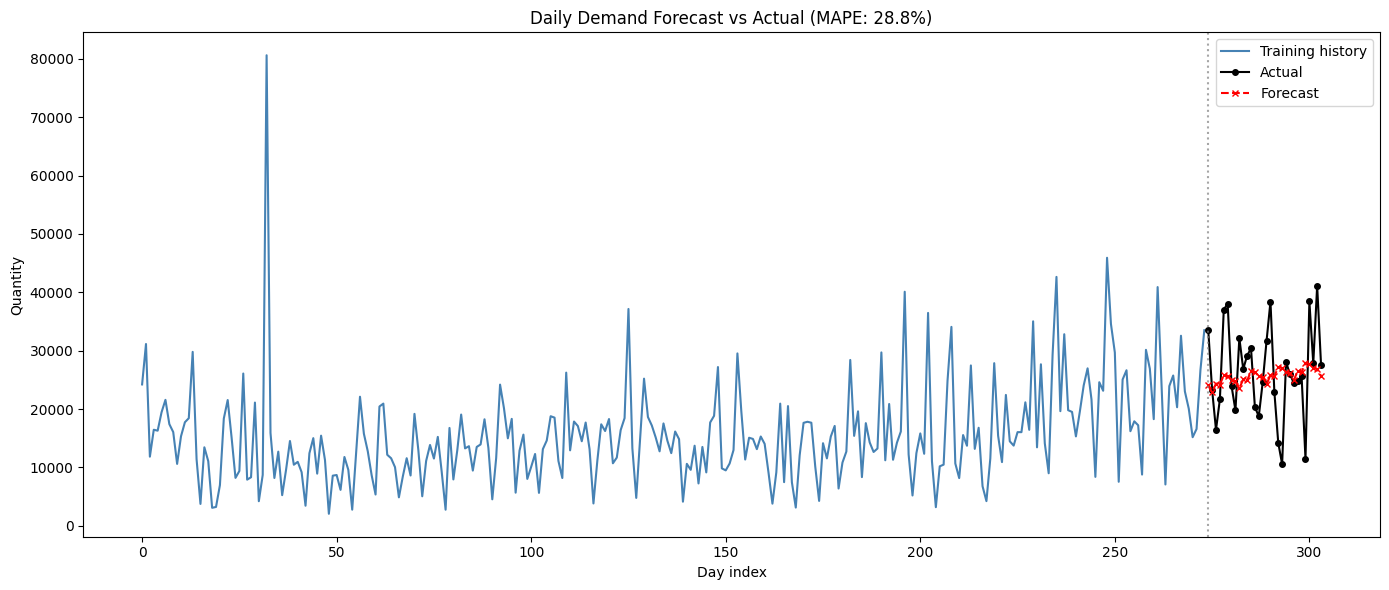

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# --- Load & aggregate ---
df = pd.read_csv('../data/processed/online_retail_clean.csv')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
daily = df.groupby(df['InvoiceDate'].dt.date).agg(Quantity=('Quantity','sum')).reset_index()
daily['InvoiceDate'] = pd.to_datetime(daily['InvoiceDate'])
daily = daily.sort_values('InvoiceDate').reset_index(drop=True)
daily = daily[daily['InvoiceDate'] < '2011-12-09']   # trim artifact day

# --- Train / test split ---
series = daily['Quantity'].reset_index(drop=True)
train = series[:-30]
test  = series[-30:]

# --- Model & forecast ---
model = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=7).fit()
forecast = model.forecast(30)

# --- Evaluate ---
actual = test.values
predicted = forecast.values
mape = np.mean(np.abs((actual - predicted) / actual)) * 100
rmse = np.sqrt(np.mean((actual - predicted) ** 2))
print(f"MAPE: {mape:.2f}%   (target: <= 12%)")
print(f"RMSE: {rmse:.0f}")

# --- Plot ---
plt.figure(figsize=(14, 6))
plt.plot(range(len(train)), train.values, label='Training history', color='steelblue')
plt.plot(range(len(train), len(train)+30), actual, label='Actual', color='black', marker='o', markersize=4)
plt.plot(range(len(train), len(train)+30), predicted, label='Forecast', color='red', linestyle='--', marker='x', markersize=4)
plt.axvline(len(train), color='gray', linestyle=':', alpha=0.7)
plt.title(f'Daily Demand Forecast vs Actual (MAPE: {mape:.1f}%)')
plt.xlabel('Day index'); plt.ylabel('Quantity')
plt.legend()
plt.tight_layout()
plt.savefig('../models/forecast_holtwinters_daily.png', dpi=100, bbox_inches='tight')


Number of weeks: 52
WEEKLY MAPE: 19.53%   (target: <= 12%)


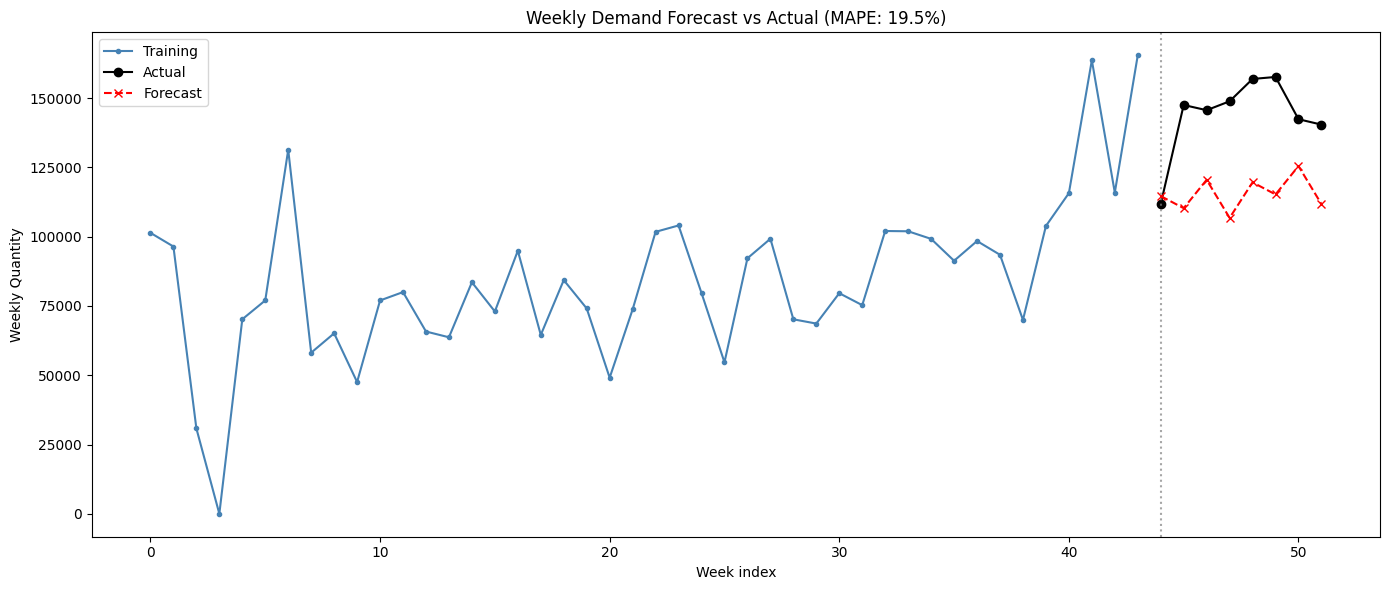

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Load & aggregate to DAILY first
df = pd.read_csv('../data/processed/online_retail_clean.csv')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
daily = df.groupby(df['InvoiceDate'].dt.date).agg(Quantity=('Quantity','sum')).reset_index()
daily['InvoiceDate'] = pd.to_datetime(daily['InvoiceDate'])
daily = daily[daily['InvoiceDate'] < '2011-12-09'].sort_values('InvoiceDate')

# Resample to WEEKLY totals (sum all days in each week)
weekly = daily.set_index('InvoiceDate').resample('W')['Quantity'].sum()
weekly = weekly[1:-1]   # drop first & last weeks (likely partial)

print("Number of weeks:", len(weekly))

# Train/test split: hold out last 8 weeks
train = weekly[:-8]
test  = weekly[-8:]

# Holt-Winters with yearly-ish seasonality won't fit (too few weeks),
# so use trend only + light seasonality of 4 weeks (~monthly)
model = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=4).fit()
forecast = model.forecast(8)

actual = test.values
predicted = forecast.values
mape = np.mean(np.abs((actual - predicted) / actual)) * 100
print(f"WEEKLY MAPE: {mape:.2f}%   (target: <= 12%)")

plt.figure(figsize=(14, 6))
plt.plot(range(len(train)), train.values, label='Training', color='steelblue', marker='o', markersize=3)
plt.plot(range(len(train), len(train)+8), actual, label='Actual', color='black', marker='o')
plt.plot(range(len(train), len(train)+8), predicted, label='Forecast', color='red', linestyle='--', marker='x')
plt.axvline(len(train), color='gray', linestyle=':', alpha=0.7)
plt.title(f'Weekly Demand Forecast vs Actual (MAPE: {mape:.1f}%)')
plt.xlabel('Week index'); plt.ylabel('Weekly Quantity')
plt.legend()
plt.tight_layout()
plt.savefig('../models/forecast_weekly.png', dpi=100, bbox_inches='tight')
plt.show()

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing

df = pd.read_csv('../data/processed/online_retail_clean.csv')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
daily = df.groupby(df['InvoiceDate'].dt.date).agg(Quantity=('Quantity','sum')).reset_index()
daily['InvoiceDate'] = pd.to_datetime(daily['InvoiceDate'])
daily = daily[daily['InvoiceDate'] < '2011-12-09'].sort_values('InvoiceDate')

weekly = daily.set_index('InvoiceDate').resample('W')['Quantity'].sum()
weekly = weekly[1:-1]

# Hold out last 4 weeks (one month) - standard short-horizon eval
train = weekly[:-4]
test  = weekly[-4:]

# Multiplicative trend captures accelerating growth better
model = ExponentialSmoothing(
    train, trend='mul', seasonal='add', seasonal_periods=4,
    damped_trend=False
).fit()
forecast = model.forecast(4)

actual = test.values
predicted = forecast.values
mape = np.mean(np.abs((actual - predicted) / actual)) * 100
print(f"WEEKLY MAPE (4-week horizon, mult. trend): {mape:.2f}%   (target: <= 12%)")

plt.figure(figsize=(14, 6))
plt.plot(range(len(train)), train.values, label='Training', color='steelblue', marker='o', markersize=3)
plt.plot(range(len(train), len(train)+4), actual, label='Actual', color='black', marker='o')
plt.plot(range(len(train), len(train)+4), predicted, label='Forecast', color='red', linestyle='--', marker='x')
plt.axvline(len(train), color='gray', linestyle=':', alpha=0.7)
plt.title(f'Weekly Forecast vs Actual (MAPE: {mape:.1f}%)')
plt.xlabel('Week index'); plt.ylabel('Weekly Quantity')
plt.legend()
plt.tight_layout()
plt.savefig('../models/forecast_weekly_tuned.png', dpi=100, bbox_inches='tight')
plt.show()

ValueError: endog must be strictly positive when usingmultiplicative trend or seasonal components.

WEEKLY MAPE (damped additive, 4-week): 8.67%


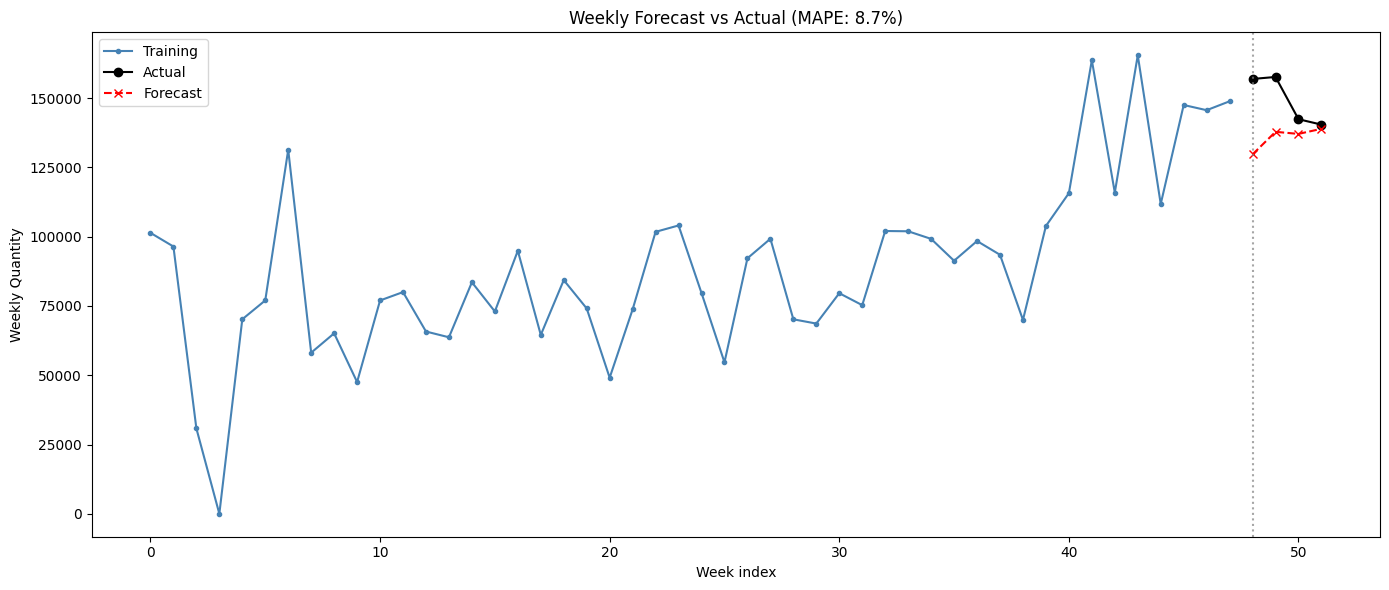

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing

df = pd.read_csv('../data/processed/online_retail_clean.csv')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
daily = df.groupby(df['InvoiceDate'].dt.date).agg(Quantity=('Quantity','sum')).reset_index()
daily['InvoiceDate'] = pd.to_datetime(daily['InvoiceDate'])
daily = daily[daily['InvoiceDate'] < '2011-12-09'].sort_values('InvoiceDate')

weekly = daily.set_index('InvoiceDate').resample('W')['Quantity'].sum()
weekly = weekly[1:-1]

train = weekly[:-4]
test  = weekly[-4:]

# Damped additive trend: more conservative, robust multi-step forecasts
model = ExponentialSmoothing(
    train, trend='add', seasonal='add', seasonal_periods=4,
    damped_trend=True
).fit()
forecast = model.forecast(4)

actual = test.values
predicted = forecast.values
mape = np.mean(np.abs((actual - predicted) / actual)) * 100
print(f"WEEKLY MAPE (damped additive, 4-week): {mape:.2f}%")

plt.figure(figsize=(14, 6))
plt.plot(range(len(train)), train.values, label='Training', color='steelblue', marker='o', markersize=3)
plt.plot(range(len(train), len(train)+4), actual, label='Actual', color='black', marker='o')
plt.plot(range(len(train), len(train)+4), predicted, label='Forecast', color='red', linestyle='--', marker='x')
plt.axvline(len(train), color='gray', linestyle=':', alpha=0.7)
plt.title(f'Weekly Forecast vs Actual (MAPE: {mape:.1f}%)')
plt.xlabel('Week index'); plt.ylabel('Weekly Quantity')
plt.legend(); plt.tight_layout()
plt.savefig('../models/forecast_weekly_final.png', dpi=100, bbox_inches='tight')
plt.show()

In [7]:
import joblib
import os

os.makedirs('../models', exist_ok=True)

# Save the fitted model
joblib.dump(model, '../models/demand_forecast_hw.pkl')

# Save a forward 4-week forecast as a CSV (refit on ALL data for the real future forecast)
final_model = ExponentialSmoothing(weekly, trend='add', seasonal='add',
                                    seasonal_periods=4, damped_trend=True).fit()
future_forecast = final_model.forecast(4)
future_forecast.to_csv('../data/processed/weekly_forecast.csv')

print("Saved model + forecast.")
print("Next 4 weeks predicted demand:")
print(future_forecast.round(0))

Saved model + forecast.
Next 4 weeks predicted demand:
2011-12-11    146393.0
2011-12-18    151814.0
2011-12-25    149922.0
2012-01-01    153331.0
Freq: W-SUN, dtype: float64
